## Evaluación del modelo

Describiendo los datos


FuelConsumption.csv,  contiene la clasificaciones de consumo de combustible específicas del modelo y emisiones estimadas de dióxido de carbono para vehículos livianos nuevos en el mercado Canadiense del año 2014 [Dataset](https://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64)

- **MODELYEAR** : Año del modelo, todos son del 2014
- **MAKE** : Marca del auto
- **MODEL** : Modelo
- **VEHICLE CLASS**  : Tipo de vehiculo
- **ENGINE SIZE** : Tamaño del motor (total del desplazamiento de todos los cilindros en litros)
- **CYLINDERS** : Número de cilindros
- **TRANSMISSION** : TIpo de transmisión
- **FUEL CONSUMPTION in CITY(L/100 km)** : Consumo de combustible en litros por km en la ciudad.
- **FUEL CONSUMPTION in HWY (L/100 km)** : Consumo de combustible en litros por km en la autopista.
- **FUEL CONSUMPTION COMB (L/100 km)** : Consumo de combustible en litros por km en ciudad  y autopista.
- **CO2 EMISSIONS (g/km)** : Emisiones de CO2 en gramos por kilometro 

Ref English : https://www.nrcan.gc.ca/energy-efficiency/transportation-alternative-fuels/personal-vehicles/choosing-right-vehicle/buying-electric-vehicle/understanding-the-tables/21383

In [1]:
'''
Curso : Análisis de Datos con Python
Fecha : 17/01/2026
Update : 13/06/2026
'''

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('dataset/FuelConsumption.csv')
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [3]:
df.dtypes

MODELYEAR                     int64
MAKE                         object
MODEL                        object
VEHICLECLASS                 object
ENGINESIZE                  float64
CYLINDERS                     int64
TRANSMISSION                 object
FUELTYPE                     object
FUELCONSUMPTION_CITY        float64
FUELCONSUMPTION_HWY         float64
FUELCONSUMPTION_COMB        float64
FUELCONSUMPTION_COMB_MPG      int64
CO2EMISSIONS                  int64
dtype: object

In [5]:
# Búsqueda de nulos
df.isnull().sum()

MODELYEAR                   0
MAKE                        0
MODEL                       0
VEHICLECLASS                0
ENGINESIZE                  0
CYLINDERS                   0
TRANSMISSION                0
FUELTYPE                    0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
dtype: int64

In [6]:
# Estadísticas descriptivas
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [7]:
# Estadísticas descriptivas para variables categóricas
df.describe(include=[object])

,MAKE,MODEL,VEHICLECLASS,TRANSMISSION,FUELTYPE
count,1067,1067,1067,1067,1067
unique,39,663,16,22,4
top,FORD,F150 FFV,MID-SIZE,A6,X
freq,90,8,178,222,514


In [17]:
df.corr(numeric_only=True)

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
MODELYEAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENGINESIZE,NaN,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,NaN,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,NaN,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,NaN,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,NaN,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,NaN,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,NaN,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


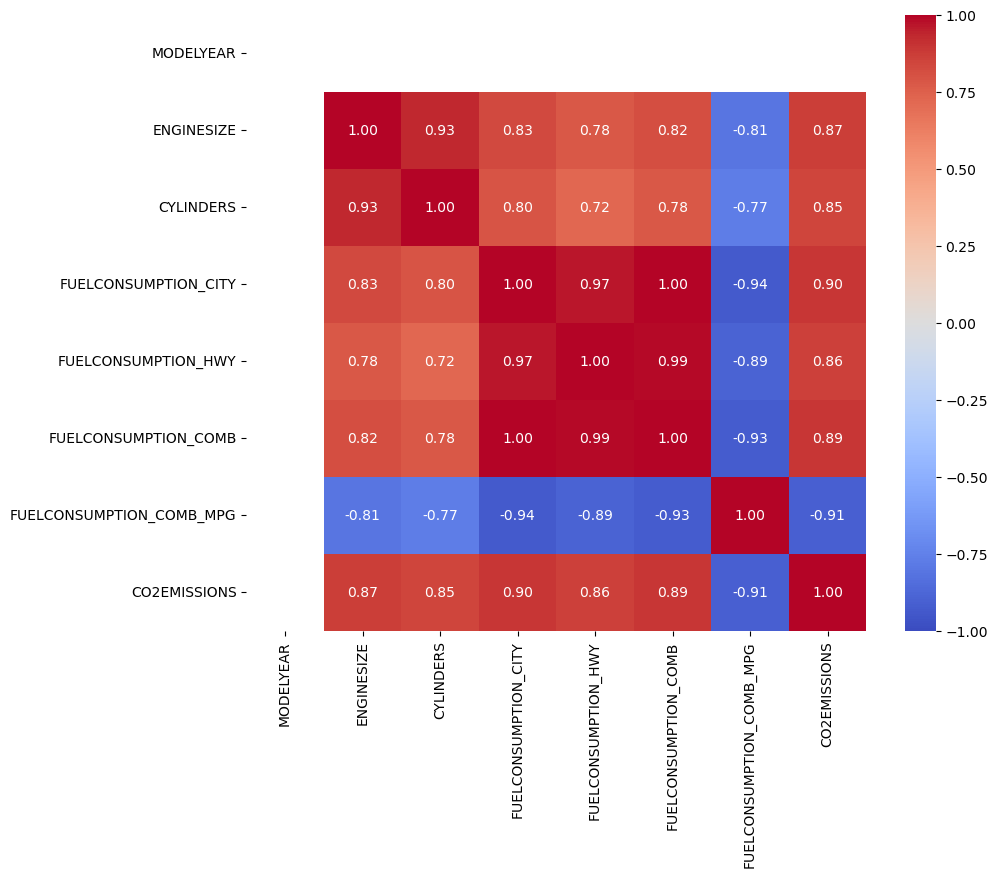

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.show()

In [8]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


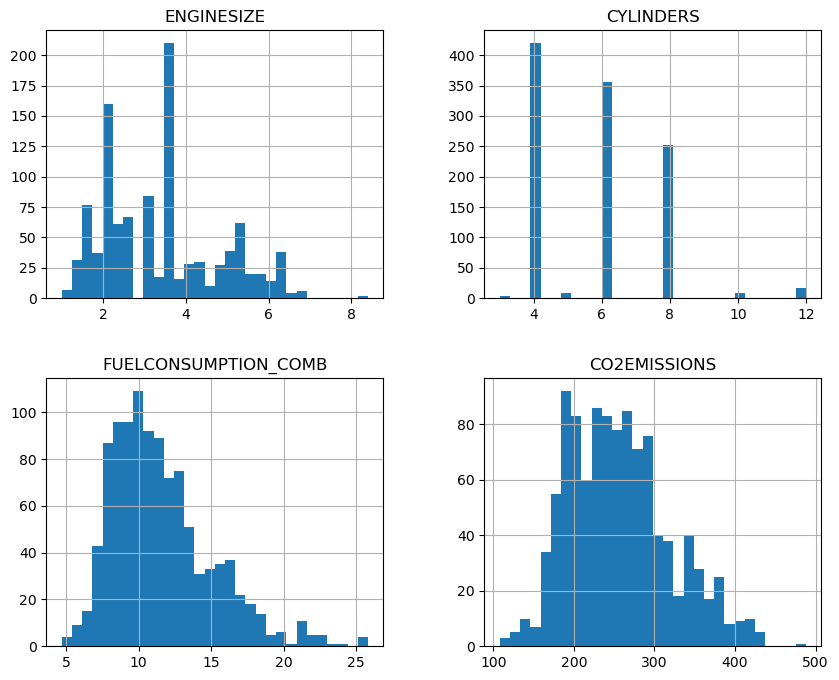

In [544]:
df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']].hist(bins=30, figsize=(10,8))
plt.show()

Generando diagramas de Regresión

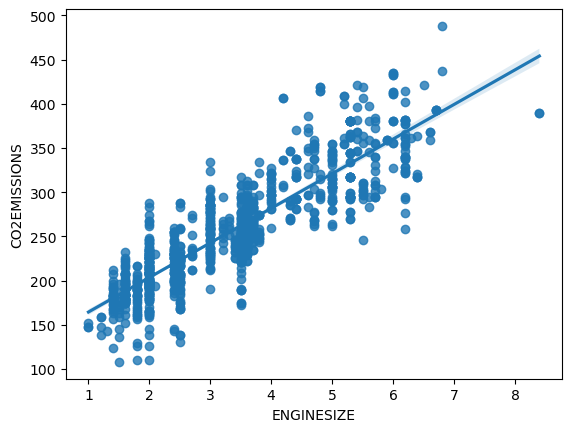

In [18]:
sns.regplot(x="ENGINESIZE", y="CO2EMISSIONS", data=cdf)
plt.show()

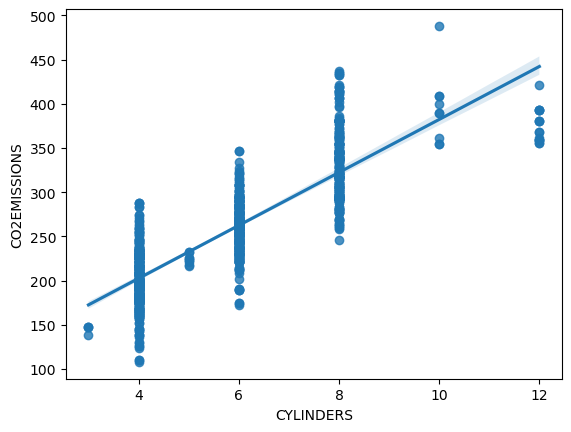

In [20]:
sns.regplot(x="CYLINDERS", y="CO2EMISSIONS", data=cdf)
plt.show()

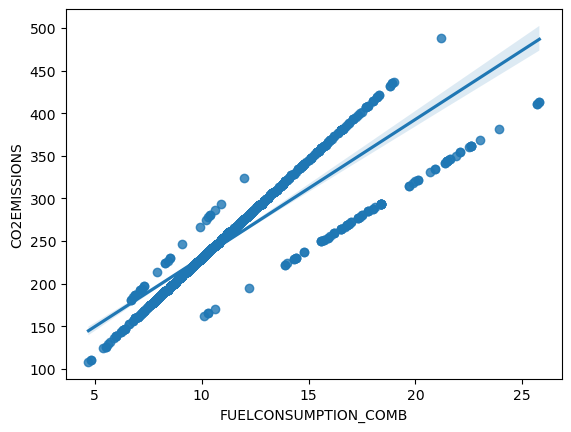

In [19]:
sns.regplot(x="FUELCONSUMPTION_COMB", y="CO2EMISSIONS", data=cdf  )   
plt.show()

# PARTE 1: Modelo de regresión simple una sola variable predictora

### 3. Seleccionando variable independiente y dependiente y separando datos en entrenamiento y prueba


In [22]:
X = cdf[['ENGINESIZE']]
y = cdf['CO2EMISSIONS']

print("Tamaño de X:", X.shape)

print(type(y))
print(type(X))

Tamaño de X: (1067, 1)
<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("------- Train Data -------")
print("Tamaño de X_train:", X_train.shape)
print("Tamaño de y_train:", y_train.shape)

print("------- Test Data -------")
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_test:", y_test.shape)

------- Train Data -------
Tamaño de X_train: (853, 1)
Tamaño de y_train: (853,)
------- Test Data -------
Tamaño de X_test: (214, 1)
Tamaño de y_test: (214,)


### 4.- Aplicando regresión simple, mostrando los coeficientes y escribiendo la ecuación


In [33]:
from sklearn.linear_model import LinearRegression

# El modelo 'lm' de regresión lineal se ajusta a los datos de entrenamiento
lm = LinearRegression()
#lm.fit(X, y) 

lm.fit(X_train, y_train) 

print("Coeficiente:", lm.coef_)
print("Intercepción:", lm.intercept_)

Coeficiente: [38.99297872]
Intercepción: 126.28970217408764


$$ \hat{y} = 126.29 + 38.99x $$

### 4.-Calculando valores predichos, errores, graficando la ecuación y los residuos de los datos de entrenamiento


In [34]:
df_train = pd.concat([X_train, y_train], axis=1)
df_train.head()

,ENGINESIZE,CO2EMISSIONS
333,1.4,179
106,4.4,292
585,3.0,267
55,3.0,262
213,5.3,380


#### Graficamos el modelo

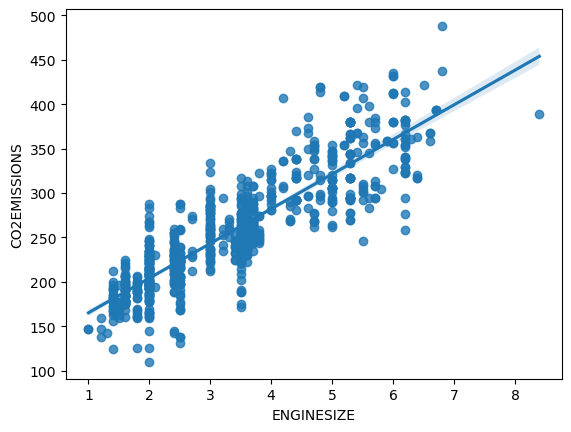

In [32]:
sns.regplot(x="ENGINESIZE", y="CO2EMISSIONS", data=df_train, fit_reg=True)
plt.show()

####  Graficamos los residuales ( usando los datos de entrenamiento)

In [35]:
df_train["ERROR"] = y_train - lm.predict(X_train)
df_train["ERROR"].head()

333    -1.879872
106    -5.858809
585    23.731362
55     18.731362
213    47.047511
Name: ERROR, dtype: float64

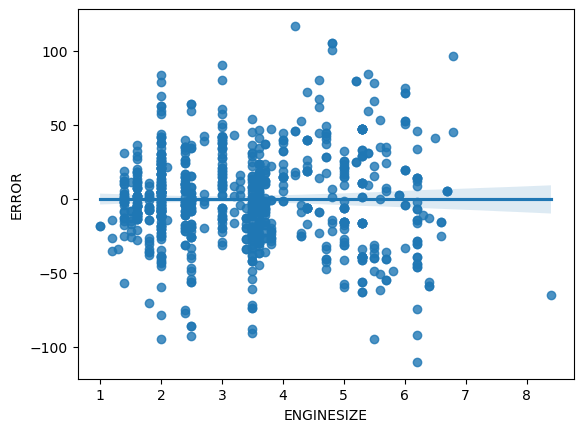

In [36]:
sns.regplot(x="ENGINESIZE", y="ERROR", data=df_train, fit_reg=True)
plt.show()

### 5.- Calculando valores predichos, errores, graficando la ecuación y los residuos de los datos de prueba


In [38]:
df_test = pd.concat([X_test, y_test], axis=1)
df_test.head()

,ENGINESIZE,CO2EMISSIONS
732,4.7,304
657,3.5,221
168,3.6,294
86,3.0,221
411,2.0,207


#### Graficamos el modelo (con los datos de prueba)

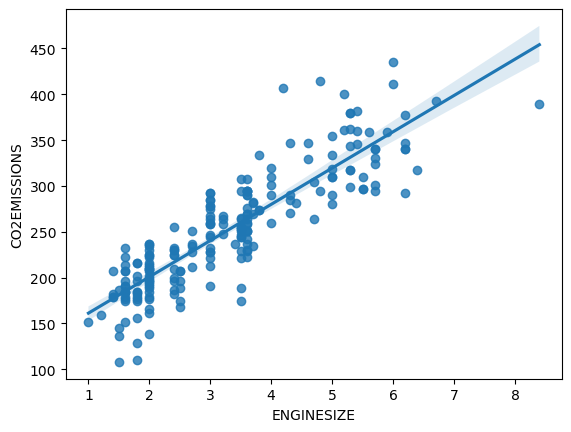

In [556]:
sns.regplot(x="ENGINESIZE", y="CO2EMISSIONS", data=df_test, fit_reg=True)
plt.show()

####  Graficamos los residuales (con los datos de prueba)

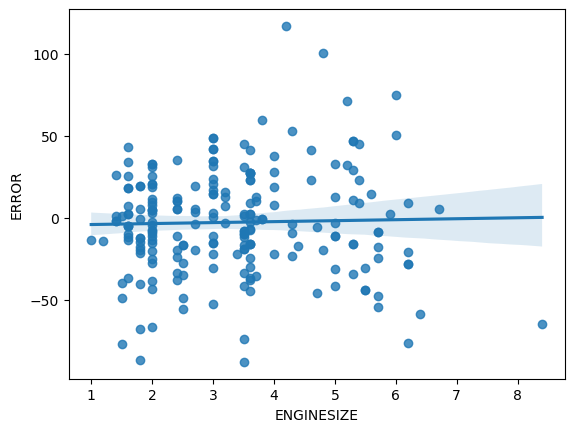

In [39]:
df_test["ERROR"] = y_test - lm.predict(X_test)
sns.regplot(x="ENGINESIZE", y="ERROR", data=df_test, fit_reg=True)
plt.show()

### 6.- Calculando MSE y R2 para modelo de regresion simple en los datos de entrenamiento y prueba


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_train_hat = lm.predict(X_train)
print("MAE train:", mean_absolute_error(y_train, y_train_hat))
print("MSE train:", mean_squared_error(y_train, y_train_hat))
print("R2 train:", r2_score(y_train, y_train_hat))


y_test_hat = lm.predict(X_test)
print("MAE test:", mean_absolute_error(y_test, y_test_hat))
print("MSE test:", mean_squared_error(y_test, y_test_hat))
print("R2 test:", r2_score(y_test, y_test_hat))

MAE train: 23.19873782395719
MSE train: 936.7860103082572
R2 train: 0.7644042001810549
MAE test: 24.097257411707844
MSE test: 985.9381692275001
R2 test: 0.7615595731934373


### 7.- Haciendo predicciones y calculando métrica para regresión simple mediante validación cruzada


In [42]:
X = cdf[['ENGINESIZE']]
y = cdf['CO2EMISSIONS']

model = LinearRegression()

### **Valización Cruzada**

Es muy útil para validar que el modelo de aprendizaje automático elegido es el correcto y ayuda a evitar el overfitting.


<img src="images/kfold.jpg" width="400"/>


Documentacion 
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html

In [43]:
from sklearn.model_selection import cross_val_predict

y_cv_hat = cross_val_predict(model, X, y, cv=5)
y_cv_hat[0:5]

array([201.70277046, 217.41090047, 182.06760795, 260.608258  ,
       260.608258  ])

In [44]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("R2 scores for each fold:", scores)
print("Mean R2 score:", scores.mean())


R2 scores for each fold: [0.74334613 0.7838278  0.72801992 0.73032948 0.78636053]
Mean R2 score: 0.7543767707250393


### 8.- Calculando métricas de desempeño para regresión simple mediante validación cruzada


In [45]:
from sklearn.model_selection import cross_validate

list_scoring = ['r2', 'neg_mean_squared_error']
list_scores = cross_validate(model, X, y, cv=5, scoring=list_scoring, return_train_score=False)

df_scores = pd.DataFrame(list_scores)
df_scores.head()

,fit_time,score_time,test_r2,test_neg_mean_squared_error
0,0.006289,0.002535,0.743346,-880.019764
1,0.003101,0.000587,0.783828,-1055.037158
2,0.000835,0.000640,0.728020,-1075.619670
3,0.000533,0.000560,0.730329,-1023.274235
4,0.000498,0.000532,0.786361,-747.383399


In [46]:
MSE_test = -list_scores['test_neg_mean_squared_error']
print("MSE test for each fold:", MSE_test)
print("Mean MSE test:", MSE_test.mean())

R2_test = list_scores['test_r2']
print("R2 test for each fold:", R2_test)
print("Mean R2 test:", R2_test.mean())


MSE test for each fold: [ 880.01976439 1055.03715804 1075.61966982 1023.27423464  747.38339934]
Mean MSE test: 956.2668452461579
R2 test for each fold: [0.74334613 0.7838278  0.72801992 0.73032948 0.78636053]
Mean R2 test: 0.7543767707250393


In [47]:
from sklearn.model_selection import cross_validate

list_scoring = ['r2', 'neg_mean_squared_error']
list_scores = cross_validate(model, X, y, cv=5, scoring=list_scoring, return_train_score=True)

df_scores = pd.DataFrame(list_scores)
df_scores.head()

,fit_time,score_time,test_r2,train_r2,test_neg_mean_squared_error,train_neg_mean_squared_error
0,0.003792,0.000691,0.743346,0.764833,-880.019764,-966.430448
1,0.000641,0.000698,0.783828,0.757121,-1055.037158,-919.550324
2,0.000637,0.000656,0.728020,0.772190,-1075.619670,-914.742235
3,0.000607,0.000645,0.730329,0.769227,-1023.274235,-928.436812
4,0.000549,0.000596,0.786361,0.756613,-747.383399,-996.858715


In [48]:
MSE_train = -list_scores['train_neg_mean_squared_error']
print("MSE train for each fold:", MSE_train)
print("Mean MSE train:", MSE_train.mean())

R2_train = list_scores['train_r2']
print("R2 train for each fold:", R2_train)
print("Mean R2 train:", R2_train.mean())

MSE train for each fold: [966.43044831 919.5503243  914.74223494 928.43681233 996.85871542]
Mean MSE train: 945.2037070617034
R2 train for each fold: [0.76483329 0.75712109 0.77218984 0.76922695 0.75661337]
Mean R2 train: 0.763996907116833


### 9.- Coeficientes para regresión simple mediante validación cruzada


In [49]:
from sklearn.model_selection import cross_validate

estimators = cross_validate(model, X, y, cv=5, return_estimator=True)

df_estimators = pd.DataFrame(estimators)
df_estimators.head()

,fit_time,score_time,estimator,test_score
0,0.006415,0.000860,LinearRegression(),0.743346
1,0.000875,0.000505,LinearRegression(),0.783828
2,0.000622,0.000360,LinearRegression(),0.728020
3,0.000439,0.000307,LinearRegression(),0.730329
4,0.000403,0.000309,LinearRegression(),0.786361


In [50]:
for i, est in enumerate(estimators['estimator']):
    print(f"Estimator {i} coefficients: {est.coef_}, intercept: {est.intercept_}")

Estimator 0 coefficients: [39.27032503], intercept: 123.16212040430028
Estimator 1 coefficients: [38.77237039], intercept: 126.8853840622669
Estimator 2 coefficients: [39.51513913], intercept: 123.51055848424673
Estimator 3 coefficients: [39.17922779], intercept: 126.14743687399331
Estimator 4 coefficients: [38.80652617], intercept: 127.10513637542542


### 10.- Creando función para gráfico de distribución


In [51]:
def distribution_plot(RedFunction, BlueFunction, RedName, BlueName, Title):
    plt.figure(figsize=(6, 6))
    sns.kdeplot(RedFunction, color="red", label=RedName)
    sns.kdeplot(BlueFunction, color="blue", label=BlueName)
    plt.title(Title)
    plt.xlabel('Emisión de CO2')
    plt.ylabel('Tamaño del motor del auto')
    plt.legend()
    plt.show()

### 11.- Realizando gráficos de predicciones para datos de entrenamiento y prueba


In [52]:
from sklearn.linear_model import LinearRegression

# Entrenamiento del modelo
lm = LinearRegression()
lm.fit(X_train, y_train) 

# Valores calculados
y_train_hat = lm.predict(X_train)
y_test_hat = lm.predict(X_test)


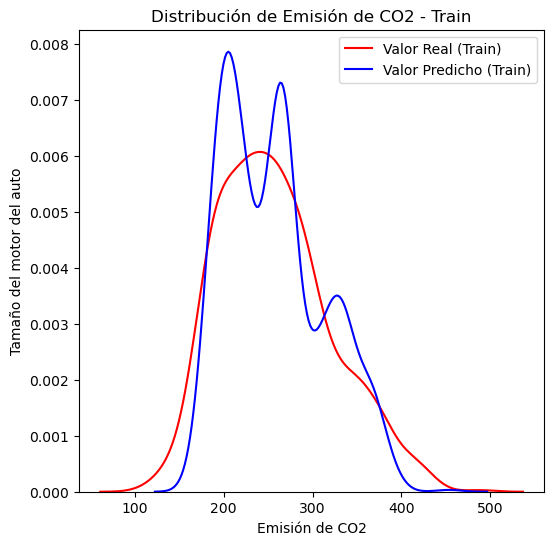

In [53]:
# Distribución de los valores reales vs valores predichos - Train data
distribution_plot(y_train, y_train_hat, "Valor Real (Train)", "Valor Predicho (Train)", "Distribución de Emisión de CO2 - Train")   

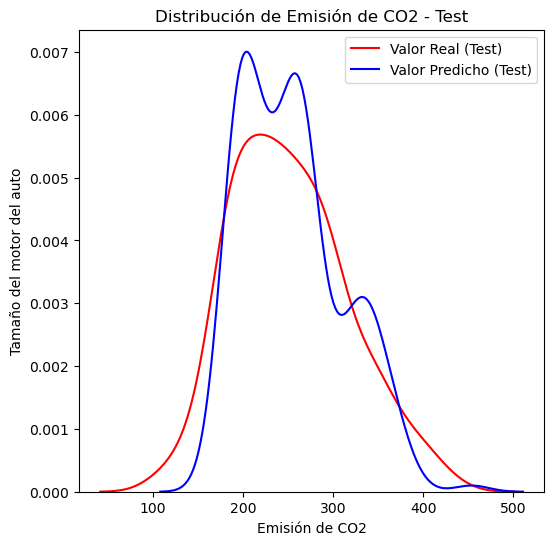

In [571]:
# Distribución de los valores reales vs valores predichos - Test data
distribution_plot(y_test, y_test_hat, "Valor Real (Test)", "Valor Predicho (Test)", "Distribución de Emisión de CO2 - Test")   

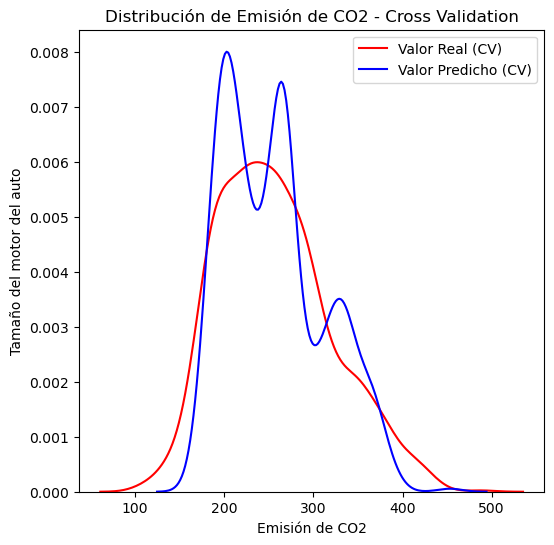

In [54]:
# Distribución de los valores reales vs valores predichos - Cross Validation data
distribution_plot(y, y_cv_hat, "Valor Real (CV)", "Valor Predicho (CV)", "Distribución de Emisión de CO2 - Cross Validation")

# PARTE 2: Modelo de regresión con varias variables predictora

In [55]:
X = cdf[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']]
y = cdf['CO2EMISSIONS']

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("------- Train Data -------")
print("Tamaño de X_train:", X_train.shape)
print("Tamaño de y_train:", y_train.shape)

print("------- Test Data -------")
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_test:", y_test.shape)


------- Train Data -------
Tamaño de X_train: (853, 3)
Tamaño de y_train: (853,)
------- Test Data -------
Tamaño de X_test: (214, 3)
Tamaño de y_test: (214,)


In [58]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train, y_train) 

print("Coeficiente:", lm.coef_)
print("Intercepción:", lm.intercept_)

Coeficiente: [11.2094395   7.15561381  9.5208118 ]
Intercepción: 67.34838518362108


$$ \hat{y} = 67.35 + 11.21x_{1} + 7.16x_{2} + 9.52x_{3} $$

Donde
- $x_{1}$ :'ENGINESIZE'
- $x_{2}$ :'CYLINDERS'
- $x_{3}$ :'FUELCONSUMPTION_COMB'

### Análisis de los residuales

In [59]:
df_train = pd.concat([X_train, y_train], axis=1)

# Y estimado
y_train_hat = lm.predict(X_train)

# Residuales
residuales = y_train - y_train_hat

residuales.head()

333    -6.926388
106    -2.829139
585    28.833577
55      9.552359
213    38.903280
Name: CO2EMISSIONS, dtype: float64

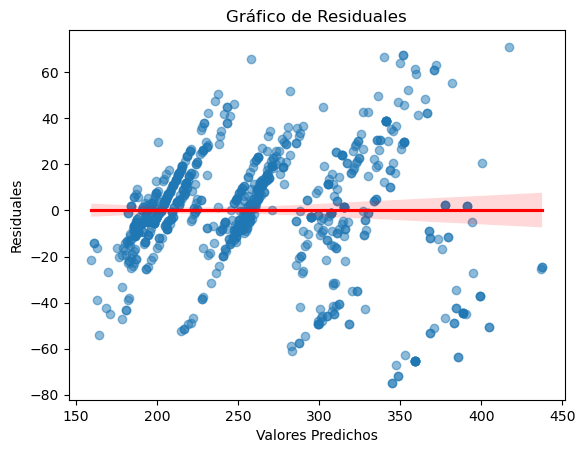

In [61]:

sns.regplot(x=y_train_hat, y=residuales, 
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red'})
#plt.axhline(y=0, color='green', linestyle='--', linewidth=2)
plt.xlabel('Valores Predichos')
plt.ylabel('Residuales')
plt.title('Gráfico de Residuales')
plt.show()

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_train_hat = lm.predict(X_train)
print("MAE train:", mean_absolute_error(y_train, y_train_hat))
print("MSE train:", mean_squared_error(y_train, y_train_hat))
print("R2 train:", r2_score(y_train, y_train_hat))

y_test_hat = lm.predict(X_test)
print("MAE test:", mean_absolute_error(y_test, y_test_hat))
print("MSE test:", mean_squared_error(y_test, y_test_hat))
print("R2 test:", r2_score(y_test, y_test_hat))

MAE train: 16.980180766116078
MSE train: 554.3023826742203
R2 train: 0.860596431041164
MAE test: 16.7215939835165
MSE test: 512.8551370148303
R2 test: 0.8759705206914069


### Cross Validation

In [64]:
from sklearn.model_selection import cross_val_predict

model2 = LinearRegression()

y_cv_hat = cross_val_predict(model, X, y, cv=5)

In [65]:
from sklearn.model_selection import cross_validate

list_scoring = ['r2', 'neg_mean_squared_error']
list_scores = cross_validate(model, X, y, cv=5, scoring=list_scoring, return_train_score=False)

df_scores = pd.DataFrame(list_scores)
df_scores.head()

,fit_time,score_time,test_r2,test_neg_mean_squared_error
0,0.002083,0.001924,0.880519,-409.678242
1,0.001979,0.001420,0.769097,-1126.933655
2,0.001212,0.000854,0.819583,-713.508189
3,0.000764,0.002937,0.884902,-436.745121
4,0.001182,0.001701,0.895584,-365.283424


In [66]:
MSE_test = -list_scores['test_neg_mean_squared_error']
print("MSE test for each fold:", MSE_test)
print("Mean MSE test:", MSE_test.mean())

R2_test = list_scores['test_r2']
print("R2 test for each fold:", R2_test)
print("Mean R2 test:", R2_test.mean())

MSE test for each fold: [ 409.67824154 1126.93365483  713.50818876  436.74512061  365.28342353]
Mean MSE test: 610.4297258541549
R2 test for each fold: [0.88051915 0.76909654 0.81958305 0.88490155 0.89558377]
Mean R2 test: 0.8499368120958023


In [67]:
from sklearn.model_selection import cross_validate

list_scoring = ['r2', 'neg_mean_squared_error']
list_scores = cross_validate(model, X, y, cv=5, scoring=list_scoring, return_train_score=True)

df_scores = pd.DataFrame(list_scores)
df_scores.head()

,fit_time,score_time,test_r2,train_r2,test_neg_mean_squared_error,train_neg_mean_squared_error
0,0.004451,0.000944,0.880519,0.857538,-409.678242,-585.454563
1,0.000671,0.000584,0.769097,0.885363,-1126.933655,-434.021830
2,0.000557,0.000557,0.819583,0.873981,-713.508189,-506.011106
3,0.000531,0.000520,0.884902,0.856889,-436.745121,-575.758076
4,0.000508,0.000504,0.895584,0.854763,-365.283424,-594.860415


In [68]:
MSE_train = -list_scores['train_neg_mean_squared_error']
print("MSE train for each fold:", MSE_train)
print("Mean MSE train:", MSE_train.mean())

R2_train = list_scores['train_r2']
print("R2 train for each fold:", R2_train)
print("Mean R2 train:", R2_train.mean())

MSE train for each fold: [585.45456309 434.02182959 506.01110641 575.75807607 594.86041529]
Mean MSE train: 539.2211980884638
R2 train for each fold: [0.85753819 0.88536272 0.87398147 0.85688908 0.8547627 ]
Mean R2 train: 0.8657068321922399


### Graficando valores del MSE para los datos de entrenamiento y prueba


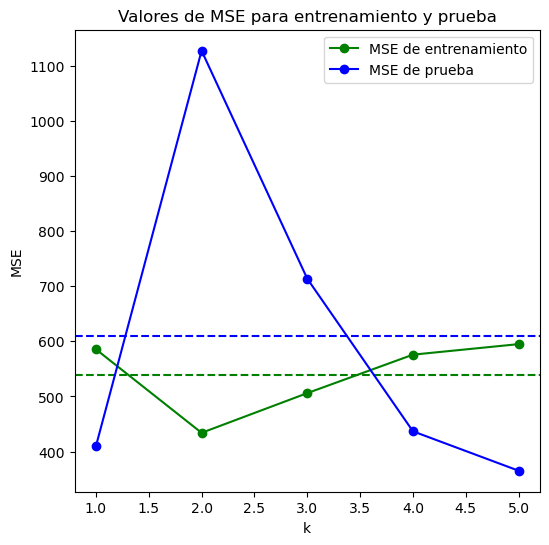

In [69]:
k = np.arange(1,len(MSE_train)+1)
plt.figure(figsize=(6,6))
plt.title('Valores de MSE para entrenamiento y prueba')
plt.plot(k,MSE_train,marker='o',linestyle='-',color='g',label='MSE de entrenamiento')
plt.axhline(y=np.mean(MSE_train),color='g',linestyle='--')
plt.plot(k,MSE_test,marker='o',linestyle='-',color='b',label='MSE de prueba')
plt.axhline(y=np.mean(MSE_test),color='b',linestyle='--')
plt.legend()
plt.xlabel('k')
plt.ylabel('MSE')
plt.show()

### Graficando valores del R2 para los datos de entrenamiento y prueba


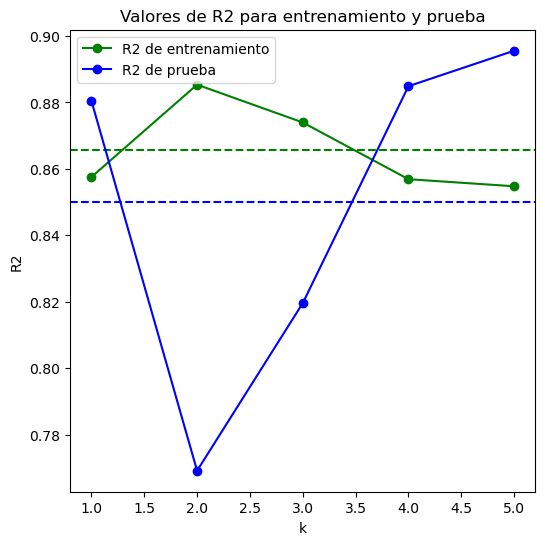

In [585]:
k = np.arange(1,len(MSE_train)+1)
plt.figure(figsize=(6,6))
plt.title('Valores de R2 para entrenamiento y prueba')
plt.plot(k,R2_train,marker='o',linestyle='-',color='g',label='R2 de entrenamiento')
plt.axhline(y=np.mean(R2_train),color='g',linestyle='--')
plt.plot(k,R2_test,marker='o',linestyle='-',color='b',label='R2 de prueba')
plt.axhline(y=np.mean(R2_test),color='b',linestyle='--')
plt.legend()
plt.xlabel('k')
plt.ylabel('R2')
plt.show()

### Coeficientes para regresión múltiple mediante validación cruzada

In [70]:
X = cdf[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']]
y = cdf['CO2EMISSIONS']
model2 = LinearRegression()

In [71]:
from sklearn.model_selection import cross_validate

estimators = cross_validate(model2, X, y, cv=5, return_estimator=True)

df_estimators = pd.DataFrame(estimators)
df_estimators.head()

,fit_time,score_time,estimator,test_score
0,0.006842,0.002071,LinearRegression(),0.880519
1,0.000905,0.000489,LinearRegression(),0.769097
2,0.000628,0.000441,LinearRegression(),0.819583
3,0.000584,0.000413,LinearRegression(),0.884902
4,0.000574,0.000404,LinearRegression(),0.895584


In [73]:
for i, est in enumerate(estimators['estimator']):
    print(f"Estimator {i} coefficients: {est.coef_}, intercept: {est.intercept_}")

Estimator 0 coefficients: [13.94836049  5.55035543  9.1577801 ], intercept: 69.91801700851971
Estimator 1 coefficients: [ 7.139617    6.93869399 11.9477128 ], intercept: 56.016653070108816
Estimator 2 coefficients: [11.56106964  7.18081943  9.86179342], intercept: 61.67098288855715
Estimator 3 coefficients: [11.81521025  7.5955932   8.88680877], intercept: 69.96805133389802
Estimator 4 coefficients: [9.94765129 9.15011706 8.90416034], intercept: 66.31504810614206


## Realizando gráficos de predicciones para datos de entrenamiento y prueba

In [74]:
from sklearn.linear_model import LinearRegression

# Entrenamiento del modelo
lm = LinearRegression()
lm.fit(X_train, y_train) 

# Valores calculados
y_train_hat = lm.predict(X_train)
y_test_hat = lm.predict(X_test)

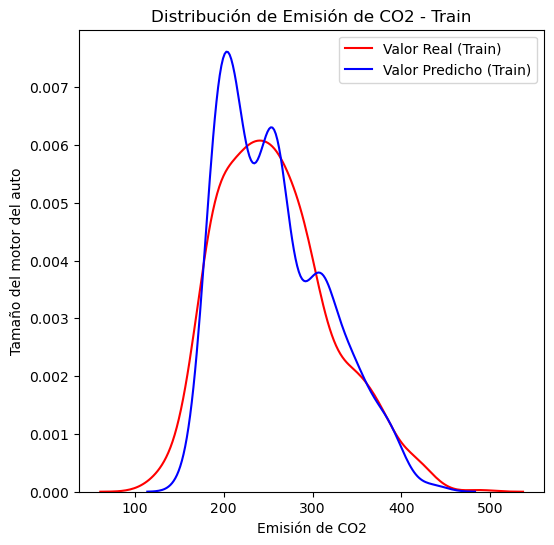

In [75]:
# Distribución de los valores reales vs valores predichos - Train data
distribution_plot(y_train, y_train_hat, "Valor Real (Train)", "Valor Predicho (Train)", "Distribución de Emisión de CO2 - Train")   

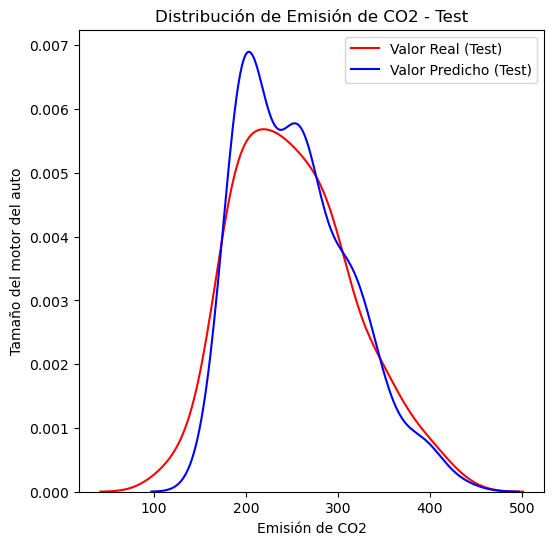

In [76]:
# Distribución de los valores reales vs valores predichos - Test data
distribution_plot(y_test, y_test_hat, "Valor Real (Test)", "Valor Predicho (Test)", "Distribución de Emisión de CO2 - Test")   

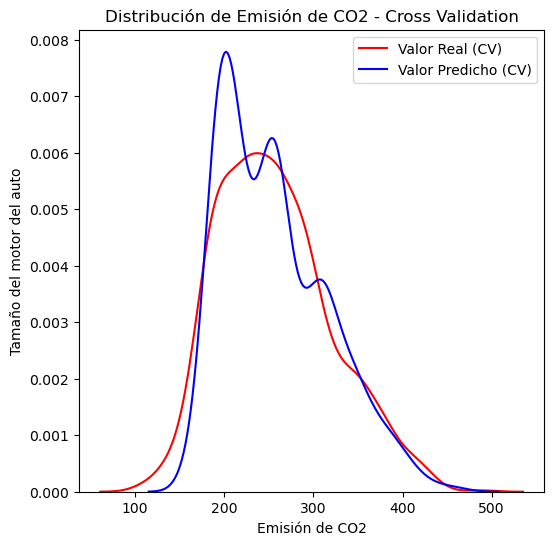

In [77]:
# Distribución de los valores reales vs valores predichos - Cross Validation data
distribution_plot(y, y_cv_hat, "Valor Real (CV)", "Valor Predicho (CV)", "Distribución de Emisión de CO2 - Cross Validation")

### AIC y BIC

In [78]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


In [82]:
# Regresión usando la librería statsmodels
import statsmodels.formula.api as smf
modelo1 = smf.ols('CO2EMISSIONS ~  ENGINESIZE', data=cdf).fit()
modelo2 = smf.ols('CO2EMISSIONS ~  CYLINDERS', data=cdf).fit()
modelo3 = smf.ols('CO2EMISSIONS ~  FUELCONSUMPTION_COMB', data=cdf).fit()
modelo4 = smf.ols('CO2EMISSIONS ~  ENGINESIZE + CYLINDERS + FUELCONSUMPTION_COMB', data=cdf).fit()

In [83]:
resultados = pd.DataFrame({
    'Modelo': ['Modelo 1', 'Modelo 2', 'Modelo 3', 'Modelo 4'],
    'AIC': [round(modelo1.aic, 2), round(modelo2.aic, 2), 
            round(modelo3.aic, 2), round(modelo4.aic, 2)],
    'BIC': [round(modelo1.bic, 2), round(modelo2.bic, 2), 
            round(modelo3.bic, 2), round(modelo4.bic, 2)]
})
resultados

,Modelo,AIC,BIC
0,Modelo 1,10343.71,10353.66
1,Modelo 2,10519.27,10529.22
2,Modelo 3,10189.45,10199.40
3,Modelo 4,9760.29,9780.18


In [84]:
for i in range(len(resultados)):
    if (resultados['AIC'][i] == np.min(resultados['AIC'])):
        min_AIC = resultados['AIC'][i]
        modelo_AIC = resultados['Modelo'][i]
    else:
        continue

print("Mejor modelo según AIC es", modelo_AIC, "con AIC =", min_AIC)

Mejor modelo según AIC es Modelo 4 con AIC = 9760.29


In [85]:
for i in range(len(resultados)):
    if (resultados['BIC'][i] == np.min(resultados['BIC'])):
        min_BIC = resultados['BIC'][i]
        modelo_BIC = resultados['Modelo'][i]
    else:
        continue

print("Mejor modelo según BIC es", modelo_BIC, "con BIC =", min_BIC)

Mejor modelo según BIC es Modelo 4 con BIC = 9780.18
